In [ ]:
import os
import time
import random
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from collections import deque
from gymnasium.wrappers import AtariPreprocessing

In [ ]:
import os
import time
import random
import gymnasium as gym
import ale_py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from collections import deque
from gymnasium.wrappers import AtariPreprocessing
from PIL import Image

In [ ]:
!pip install -q gymnasium[atari] ale-py autorom
os.makedirs("/root/.ale", exist_ok=True)
!AutoROM --accept-license --install-dir /root/.ale
os.environ["ALE_ROM_PATH"] = "/root/.ale"

envs = sorted([spec.id for spec in gym.envs.registry.values() if "Breakout" in spec.id])
print("Breakout environments:", envs)

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/root/.ale

Existing ROMs will be overwritten.
Breakout environments: ['ALE/Breakout-ram-v5', 'ALE/Breakout-v5', 'Breakout-ram-v0', 'Breakout-ram-v4', 'Breakout-ramDeterministic-v0', 'Breakout-ramDeterministic-v4', 'Breakout-ramNoFrameskip-v0', 'Breakout-ramNoFrameskip-v4', 'Breakout-v0', 'Breakout-v4', 'BreakoutDeterministic-v0', 'BreakoutDeterministic-v4', 'BreakoutNoFrameskip-v0', 'BreakoutNoFrameskip-v4']


Using device: cuda
Episode 0 | Reward: 0.5 | Avg per life: 0.12 | Eps: 1.00 | Loss: 0.0000 | Steps: 171
Episode 10 | Reward: -0.5 | Avg per life: -0.08 | Eps: 0.98 | Loss: 0.0000 | Steps: 2269
Episode 20 | Reward: 4.5 | Avg per life: 0.92 | Eps: 0.96 | Loss: 0.0000 | Steps: 4151
Episode 30 | Reward: 1.5 | Avg per life: 0.32 | Eps: 0.94 | Loss: 0.0000 | Steps: 5924
Episode 40 | Reward: 3.5 | Avg per life: 0.72 | Eps: 0.92 | Loss: 0.0000 | Steps: 8008
Target network updated at step 0
Episode 50 | Reward: 0.5 | Avg per life: 0.12 | Eps: 0.90 | Loss: 0.0109 | Steps: 10537
Target network updated at step 1000
Target network updated at step 2000
Episode 60 | Reward: 0.5 | Avg per life: 0.12 | Eps: 0.88 | Loss: 0.0055 | Steps: 12259
Target network updated at step 3000
Target network updated at step 4000
Episode 70 | Reward: 0.5 | Avg per life: 0.12 | Eps: 0.86 | Loss: 0.0042 | Steps: 14314
Target network updated at step 5000
Episode 80 | Reward: -0.5 | Avg per life: -0.08 | Eps: 0.84 | Loss: 0

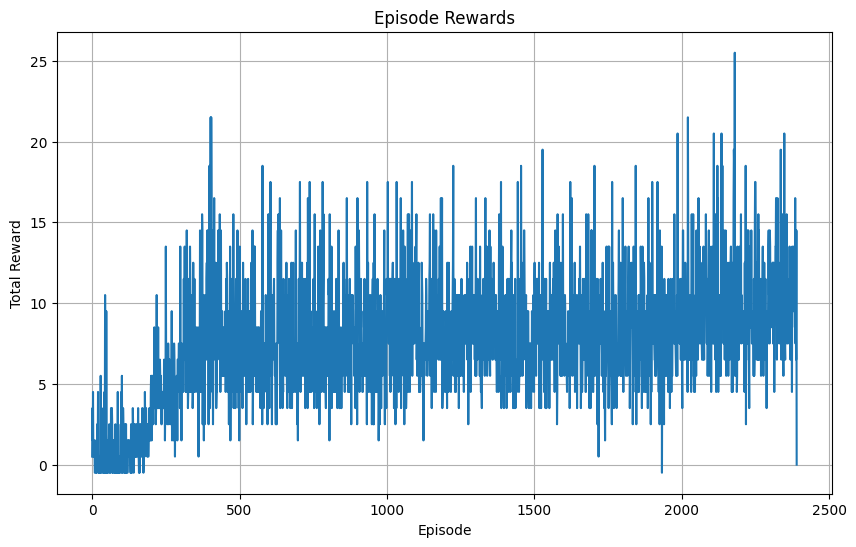

In [ ]:
BATCH_SIZE = 32
LR = 0.00025
GAMMA = 0.99
MEMORY_CAPACITY = 20000
MEMORY_START_SIZE = 10000
TARGET_UPDATE_FREQ = 1000
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 100000

class FrameStack(gym.Wrapper):
    def __init__(self, env, num_stack):
        super().__init__(env)
        self.num_stack = num_stack
        self.frames = deque(maxlen=num_stack)
        obs_space = env.observation_space
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0,
            shape=(num_stack, obs_space.shape[0], obs_space.shape[1]),
            dtype=np.float32
        )

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        for _ in range(self.num_stack):
            self.frames.append(obs)
        return np.stack(self.frames, axis=0), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.frames.append(obs)
        return np.stack(self.frames, axis=0), reward, terminated, truncated, info


class CNN(nn.Module):
    def __init__(self, in_channels, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 8, 4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(state).to(DEVICE),
            torch.LongTensor(action).to(DEVICE),
            torch.FloatTensor(reward).to(DEVICE),
            torch.FloatTensor(next_state).to(DEVICE),
            torch.FloatTensor(done).to(DEVICE)
        )

    def __len__(self):
        return len(self.buffer)


class DQN:
    def __init__(self, n_actions, in_channels):
        self.eval_net = CNN(in_channels, n_actions).to(DEVICE)
        self.target_net = CNN(in_channels, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.eval_net.state_dict())
        self.target_net.eval()

        self.memory = ReplayBuffer(MEMORY_CAPACITY)
        self.optimizer = optim.Adam(self.eval_net.parameters(), lr=LR)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=200000, gamma=0.5)
        self.steps = 0
        self.n_actions = n_actions
        self.losses = []
        self.updates = 0

        self.grad_clip = 10.0

    def get_action(self, state, epsilon):
        if random.random() < epsilon:
            action = random.randrange(self.n_actions)
            q_values = np.zeros(self.n_actions)
            return action, q_values

        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_values = self.eval_net(state_tensor)
            q_np = q_values.cpu().numpy()[0]
            action = q_values.argmax().item()
            return action, q_np

    def get_state_value(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_values = self.eval_net(state_tensor)
            max_q = q_values.max().item()
            q_np = q_values.cpu().numpy()[0]
            return max_q, q_np

    def update(self):
        if len(self.memory) < MEMORY_START_SIZE:
            return None

        self.updates += 1
        state, action, reward, next_state, done = self.memory.sample(BATCH_SIZE)

        q_values = self.eval_net(state)
        state_action = q_values.gather(1, action.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_actions = self.eval_net(next_state).max(1)[1].unsqueeze(1)
            next_q = self.target_net(next_state).gather(1, next_actions).squeeze(1)
            expected = reward + GAMMA * next_q * (1 - done)

        loss = F.smooth_l1_loss(state_action, expected)

        self.optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.eval_net.parameters(), self.grad_clip)

        self.optimizer.step()
        self.scheduler.step()

        self.losses.append(loss.item())

        if self.steps % TARGET_UPDATE_FREQ == 0:
            self.target_net.load_state_dict(self.eval_net.state_dict())
            print(f"Target network updated at step {self.steps}")

        self.steps += 1
        return loss.item()


def process_frame_for_display(frame):
    if frame is None:
        return None

    if len(frame.shape) > 3:
        frame = frame[-1]

    if len(frame.shape) == 2 or frame.shape[0] == 1:
        frame = np.repeat(frame[np.newaxis, :, :], 3, axis=0)
        frame = np.transpose(frame, (1, 2, 0))

    if frame.max() <= 1.0:
        frame = (frame * 255).astype(np.uint8)

    return frame

def setup_env(render_mode=None):
    env = gym.make("ALE/Breakout-v5", render_mode=render_mode, frameskip=1)
    env = AtariPreprocessing(env, grayscale_obs=True, scale_obs=True, frame_skip=4)
    env = FrameStack(env, num_stack=4)
    return env

def train(agent, episodes=1000, max_steps=1000000, log_interval=10, save_screenshots=False):
    env = setup_env(render_mode="rgb_array" if save_screenshots else None)
    n_actions = env.action_space.n

    rewards = []
    life_scores_all = []
    episode_lengths = []
    episode_losses = []
    state_values_over_time = []

    total_steps = 0
    best_reward = 0

    window_size = 100
    avg_rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        epsilon = max(EPSILON_END, EPSILON_START - total_steps / EPSILON_DECAY)

        episode_losses_list = []
        episode_state_values = []
        frame_screenshots = []

        try:
            _, _, _, _, info = env.step(1)
            prev_lives = info.get('lives', 5)
        except Exception as e:
            print(f"Error getting initial lives: {e}")
            prev_lives = 5

        life_reward = 0
        life_scores = []

        step = 0
        episode_step = 0

        while not done and episode_step < 10000:
            rendered_frame = None
            if save_screenshots and episode_step % 30 == 0:
                try:
                    rendered_frame = env.render()
                    frame_screenshots.append(rendered_frame)
                except Exception as e:
                    print(f"Error rendering: {e}")
                    save_screenshots = False

            action, q_values = agent.get_action(state, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            max_q, _ = agent.get_state_value(state)
            episode_state_values.append(max_q)

            try:
                current_lives = info.get('lives', prev_lives)
                life_ended = current_lives < prev_lives

                if life_ended:
                    life_scores.append(life_reward)
                    life_reward = 0
                    prev_lives = current_lives
                    reward = -0.1
            except Exception as e:
                print(f"Error tracking lives: {e}")

            agent.memory.push(state, action, reward, next_state, life_ended or done)

            state = next_state
            total_reward += reward
            life_reward += reward

            loss = agent.update()
            if loss is not None:
                episode_losses_list.append(loss)

            step += 1
            episode_step += 1
            total_steps += 1

            if total_steps >= max_steps:
                print(f"Reached maximum steps: {max_steps}")
                break

        if life_reward > 0:
            life_scores.append(life_reward)

        rewards.append(total_reward)
        life_scores_all.append(life_scores)
        episode_lengths.append(episode_step)

        if episode_losses_list:
            avg_loss = np.mean(episode_losses_list)
            episode_losses.append(avg_loss)
        else:
            episode_losses.append(0)

        state_values_over_time.append(episode_state_values)

        if len(rewards) >= window_size:
            avg_rewards.append(np.mean(rewards[-window_size:]))

            if avg_rewards[-1] > best_reward:
                best_reward = avg_rewards[-1]
                torch.save(agent.eval_net.state_dict(), 'breakout_dqn_best.pth')
                print(f"New best model saved with avg reward: {best_reward:.2f}")

        if ep % log_interval == 0:
            avg_life = np.mean(life_scores) if life_scores else 0
            avg_loss = np.mean(episode_losses_list) if episode_losses_list else 0
            print(f"Episode {ep} | Reward: {total_reward:.1f} | Avg per life: {avg_life:.2f} | "
                  f"Eps: {epsilon:.2f} | Loss: {avg_loss:.4f} | Steps: {total_steps}")

        if total_steps >= max_steps:
            break

    env.close()
    return rewards, life_scores_all, episode_losses, state_values_over_time, []

if __name__ == "__main__":
    print(f"Using device: {DEVICE}")
    start = time.time()

    env = setup_env()
    n_actions = env.action_space.n
    state_shape = env.observation_space.shape

    agent = DQN(n_actions, state_shape[0])
    rewards, life_scores_all, losses, state_values, _ = train(
        agent,
        episodes=3000,
        max_steps=1000000,
        log_interval=10,
        save_screenshots=False
    )

    training_time = time.time() - start
    print(f"Total training time: {training_time:.2f} seconds")
    print(f"Final average reward (last 100 episodes): {np.mean(rewards[-100:]):.2f}")

    torch.save(agent.eval_net.state_dict(), 'breakout_dqn_final.pth')
    print("Final model saved to 'breakout_dqn_final.pth'")

    plt.figure(figsize=(10, 6))
    plt.plot(rewards)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)
    plt.savefig('breakout_rewards.png')
    plt.show()